# 08 — Backtest : le signal survit-il aux coûts ?

**La question qui décide de tout.** Le notebook 06 a montré qu'on classe correctement les jours de gap
positif. Cela ne dit **rien** sur la rentabilité. Un signal peut être statistiquement réel et
économiquement nul.

## Le problème central : le gap ne se trade pas facilement

Pour capturer un gap, il faut :

1. **acheter à la clôture** de la veille (16h00) ;
2. **conserver la position pendant la nuit**, exposé à tout ce qui peut arriver ;
3. **vendre à l'ouverture** (9h30).

C'est ce qu'on appelle une stratégie *close-to-open*. Elle a trois coûts, et **le troisième est celui
qu'oublient la plupart des mémoires** :

| Coût | Ordre de grandeur | Nature |
|------|-------------------|--------|
| Commission | 0.5 – 2 bp | frais du courtier |
| Fourchette (spread) | 1 – 5 bp | on achète à l'ask, on vend au bid |
| **Impact à l'ouverture** | **5 – 20 bp** | l'ouverture est le moment le moins liquide de la journée |

**Le troisième coût est fatal.** À l'ouverture, la fourchette est large et le carnet mince ; c'est
précisément là que le gap se matérialise. On paie donc le plus cher au moment exact où l'on veut sortir.

## Ce que ce notebook doit établir

Le seuil de coût **au-delà duquel la stratégie cesse d'être rentable**. Ce chiffre (le *break-even*) est
plus honnête et plus informative qu'un ratio de Sharpe : il permet au lecteur de conclure lui-même selon
sa propre structure de coûts.

In [13]:
PROJET = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project"

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = os.path.join(PROJET, "data", "processed")
DOCS = os.path.join(PROJET, "docs")
os.makedirs(DOCS, exist_ok=True)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 60)
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["figure.figsize"] = (13, 6)

df = pd.read_csv(os.path.join(DATA, "DATASET_MODELISATION_2020_2022.csv"))
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

with open(os.path.join(DATA, "config_modelisation.json"), encoding="utf-8") as f:
    CFG = json.load(f)
FEATURES  = [c for c in CFG["features"] if c in df.columns]

_absentes = [c for c in CFG["features"] if c not in df.columns]
if _absentes:
    raise KeyError(f"{len(_absentes)} features déclarées dans config_modelisation.json "
                   f"sont absentes du CSV : {_absentes}\nRéexécuter le notebook 05.")
FEAT_SENT = [c for c in CFG["features_sentiment"] if c in df.columns]
FEAT_CTRL = [c for c in CFG["controles"] if c in df.columns]
print(f"{len(df):,} lignes | {len(FEATURES)} features")


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

def logit(C=1.0):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("std", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=2000, C=C))])

PURGE = CFG["purge_jours"]
def plis_wf(dates, n_plis=8, taille_test=60, min_train=250):
    j = np.sort(pd.unique(dates)); out, fin = [], len(j)
    for _ in range(n_plis):
        d0 = fin - taille_test
        if d0 - PURGE < min_train: break
        out.append((j[:d0 - PURGE], j[d0:fin])); fin = d0
    return out[::-1]

# --- Prédictions hors échantillon sur TOUTE la période disponible ---
# --------------------------------------------------------------------------
# Le walk-forward NE DOIT PAS toucher le bloc de test, sinon l'évaluation
# finale du notebook 06 §9 n'est plus en aveugle. On restreint donc toutes
# les prédictions hors échantillon aux blocs train / purge_1 / valid.
# --------------------------------------------------------------------------
BLOCS_WF = ["train", "purge_1", "valid"]
d = df[df["bloc"].isin(BLOCS_WF)].dropna(subset=["y_gap", "gap"]).copy()
plis = plis_wf(d["Date"], n_plis=8, taille_test=60)
_dernier = pd.Timestamp(plis[-1][1][-1])
_premier = df.loc[df["bloc"] == "test", "Date"].min()
print(f"Dernier jour du walk-forward : {_dernier.date()}")
print(f"Premier jour du bloc test    : {_premier.date()}")
assert _dernier < _premier, \
    "Le walk-forward empiète sur le bloc de test : le §9 ne serait plus en aveugle."
print("[OK] Le bloc de test est intact.")

blocs = []
for j_tr, j_te in plis:
    a = d[d["Date"].isin(j_tr)]; b = d[d["Date"].isin(j_te)].copy()
    if len(a) < 250 or b["y_gap"].nunique() < 2: continue
    m = clone(logit()).fit(a[FEATURES], a["y_gap"])
    b["proba"] = m.predict_proba(b[FEATURES])[:, 1]
    blocs.append(b)

P = pd.concat(blocs).sort_values(["Date", "Ticker"]).reset_index(drop=True)
print(f"{len(P):,} prédictions hors échantillon | "
      f"{P['Date'].min().date()} -> {P['Date'].max().date()} ({P['Date'].nunique()} jours)")
print(f"AUC globale hors échantillon : {roc_auc_score(P['y_gap'], P['proba']):.4f}")

2,740 lignes | 18 features
Dernier jour du walk-forward : 2021-11-30
Premier jour du bloc test    : 2021-12-06
[OK] Le bloc de test est intact.
900 prédictions hors échantillon | 2021-03-17 -> 2021-11-30 (180 jours)
AUC globale hors échantillon : 0.5994


---
## §1 — Définir la stratégie

### Les règles

À chaque clôture (16h00), pour chaque action :

| Probabilité prédite | Action |
|---------------------|--------|
| `p > seuil_haut` | **acheter** (long), garder jusqu'à l'ouverture |
| `p < seuil_bas` | **vendre à découvert** (short) |
| entre les deux | **ne rien faire** |

### Pourquoi une zone neutre

Le notebook 04 a montré que le signal est concentré dans les quintiles extrêmes (Q2, Q3 et Q4 sont plats).
Trader tous les jours revient à payer des frais sur les jours où on n'a aucune information. La zone
neutre est donc une décision **fondée sur les données**, pas un réglage arbitraire.

### Le dimensionnement

Trois variantes, de la plus simple à la plus sophistiquée :

| Variante | Taille de position |
|----------|--------------------|
| **Binaire** | ±1 dès que le seuil est franchi |
| **Proportionnelle** | proportionnelle à `p − 0.5` : plus le modèle est confiant, plus la position est grande |
| **Ajustée au risque** | proportionnelle à `(p − 0.5) / volatilité` : on prend moins de risque sur les titres volatils |

La troisième est celle d'un gérant professionnel — et c'est celle qui a le plus de sens dans un mémoire
d'actuariat, puisqu'elle égalise la contribution au risque.

In [14]:
def construire_positions(data, seuil=0.05, mode="proportionnel", vol_cible=0.02):
    """Transforme des probabilités en positions.

    seuil : distance minimale à 0.5 pour prendre position (0.05 -> agir si p<0.45 ou p>0.55).
    mode  : 'binaire' | 'proportionnel' | 'risque'
    """
    x = data.copy()
    edge = x["proba"] - 0.5
    actif = edge.abs() >= seuil

    if mode == "binaire":
        pos = np.sign(edge)
    elif mode == "proportionnel":
        pos = np.clip(edge / 0.15, -1, 1)          # saturation à p=0.65 / p=0.35
    elif mode == "risque":
        vol = x["vol_20"].replace(0, np.nan).fillna(x["vol_20"].median())
        pos = np.clip(edge / 0.15, -1, 1) * (vol_cible / vol).clip(0.25, 3.0)
    else:
        raise ValueError(mode)

    x["position"] = np.where(actif, pos, 0.0)
    return x

def backtest(data, cout_bp=10.0, cible="gap"):
    """P&L d'une stratégie close-to-open.

    Le coût porte sur le TURNOVER (variation de position) et non sur la
    position brute : maintenir une position ne coûte rien, la retourner coûte
    deux fois. C'est la convention du notebook 09, adoptée ici pour que les
    deux soient comparables.
    """
    x = data.sort_values(["Ticker", "Date"]).copy()
    x["turnover"] = (x.groupby("Ticker")["position"].diff().abs()
                       .fillna(x["position"].abs()))
    x["pnl_brut"] = x["position"] * x[cible]
    x["cout"]     = x["turnover"] * (cout_bp / 10_000)
    x["pnl_net"]  = x["pnl_brut"] - x["cout"]

    j = x.groupby("Date").agg(
        pnl_brut=("pnl_brut", "sum"), pnl_net=("pnl_net", "sum"),
        cout=("cout", "sum"), turnover=("turnover", "sum"),
        expo=("position", lambda s: s.abs().sum()),
        n_pos=("position", lambda s: (s != 0).sum()))
    j["rendement"] = np.where(j["expo"] > 0, j["pnl_net"] / j["expo"], 0.0)
    j["equity"] = (1 + j["rendement"]).cumprod()
    return x, j

def metriques(j, nom=""):
    r = j["rendement"]
    n_an = 252
    if r.std() == 0 or len(r) < 20:
        return dict(strategie=nom, jours=len(r), rendement_annuel=np.nan, vol_annuelle=np.nan,
                    sharpe=np.nan, max_drawdown=np.nan, taux_reussite=np.nan,
                    n_positions=int(j["n_pos"].sum()), cout_total_pct=np.nan)
    eq = (1 + r).cumprod()
    dd = (eq / eq.cummax() - 1).min()
    return dict(
        strategie=nom,
        jours=len(r),
        rendement_annuel=r.mean() * n_an,
        vol_annuelle=r.std() * np.sqrt(n_an),
        sharpe=r.mean() / r.std() * np.sqrt(n_an),
        max_drawdown=dd,
        taux_reussite=(r > 0).mean(),
        n_positions=int(j["n_pos"].sum()),
        cout_total_pct=j["cout"].sum() / max(j["expo"].sum(), 1e-9) * 100,
    )

print("Fonctions de backtest prêtes.")

Fonctions de backtest prêtes.


---
## §2 — L'analyse la plus importante : la sensibilité aux coûts

Plutôt que d'annoncer un ratio de Sharpe pour une hypothèse de coût arbitraire, on trace la performance
**en fonction du coût**. On obtient ainsi le **coût de break-even** : le niveau au-delà duquel la
stratégie devient perdante.

C'est le résultat le plus honnête possible, parce qu'il laisse le lecteur juger avec sa propre structure
de coûts. Et c'est le chiffre qu'un praticien regardera en premier.

RATIO DE SHARPE ANNUALISÉ selon le coût (lignes) et le seuil (colonnes)
seuil     0.00   0.03   0.05   0.08   0.12
cout_bp                                   
0        6.490  6.414  6.545  6.524  6.001
1        6.260  6.183  6.307  6.245  5.711
2        6.030  5.951  6.067  5.966  5.420
3        5.799  5.719  5.827  5.686  5.129
5        5.338  5.255  5.344  5.124  4.546
7        4.876  4.790  4.860  4.559  3.964
10       4.184  4.092  4.131  3.711  3.093
15       3.033  2.932  2.916  2.305  1.661
20       1.892  1.782  1.709  0.921  0.271
30      -0.340 -0.466 -0.645 -1.716 -2.334
50      -4.490 -4.624 -4.919 -6.219 -6.642

COÛT DE BREAK-EVEN (Sharpe = 0)
----------------------------------------------
  seuil 0.00 :   28.5 bp   (exploitable)
  seuil 0.03 :   27.9 bp   (exploitable)
  seuil 0.05 :   27.3 bp   (exploitable)
  seuil 0.08 :   23.5 bp   (exploitable)
  seuil 0.12 :   21.0 bp   (exploitable)


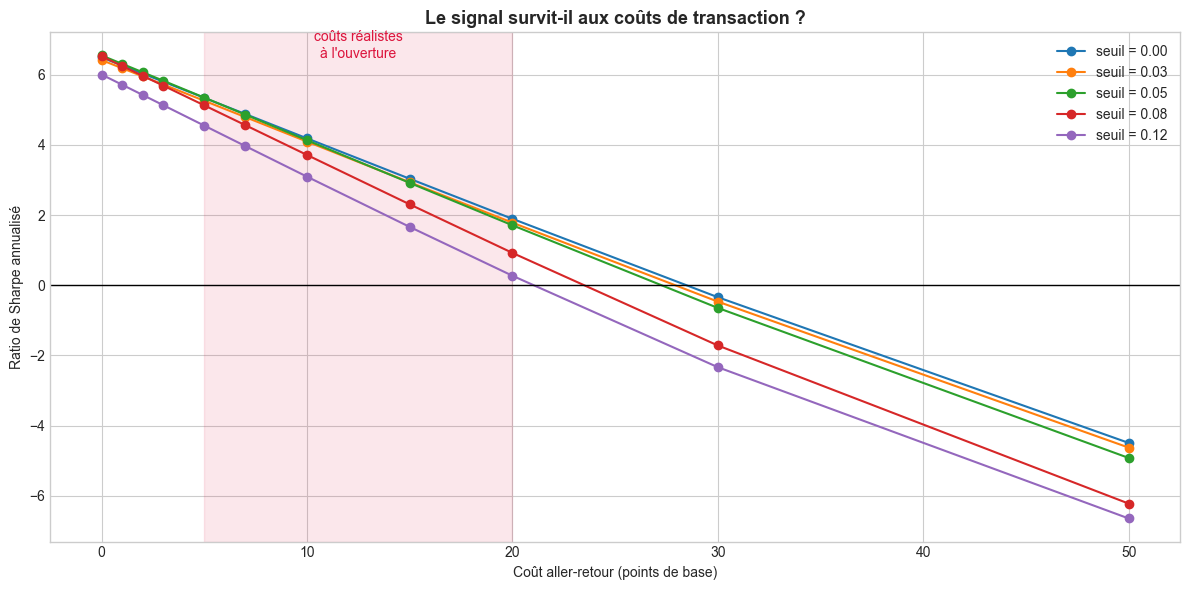


COMMENT LIRE CETTE FIGURE — c'est la conclusion économique du mémoire :
  - Si les courbes croisent zéro AVANT la zone rouge, le signal est réel
    statistiquement mais NON exploitable en pratique. C'est un résultat
    parfaitement publiable, et cohérent avec l'efficience des marchés.
  - Si elles restent positives APRÈS la zone rouge, il y a une anomalie
    exploitable -- et il faut alors redoubler de prudence sur la recherche
    de fuites avant de l'affirmer.



In [15]:
COUTS = [0, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50]
SEUILS = [0.00, 0.03, 0.05, 0.08, 0.12]

lignes = []
for seuil in SEUILS:
    pos = construire_positions(P, seuil=seuil, mode="proportionnel")
    for c_bp in COUTS:
        _, j = backtest(pos, cout_bp=c_bp)
        m = metriques(j, nom=f"seuil={seuil:.2f}")
        m.update(seuil=seuil, cout_bp=c_bp)
        lignes.append(m)

S = pd.DataFrame(lignes)
piv = S.pivot(index="cout_bp", columns="seuil", values="sharpe").round(3)
print("RATIO DE SHARPE ANNUALISÉ selon le coût (lignes) et le seuil (colonnes)")
print(piv.to_string())
S.to_csv(os.path.join(DOCS, "08_sensibilite_couts.csv"), index=False)

# Coût de break-even par seuil : interpolation linéaire du passage à Sharpe = 0
print("\nCOÛT DE BREAK-EVEN (Sharpe = 0)")
print("-" * 46)
for seuil in SEUILS:
    g = S[S["seuil"] == seuil].sort_values("cout_bp")
    sh = g["sharpe"].values; cb = g["cout_bp"].values
    be = np.nan
    for i in range(len(sh) - 1):
        if sh[i] > 0 >= sh[i + 1]:
            be = cb[i] + (cb[i+1] - cb[i]) * sh[i] / (sh[i] - sh[i+1]); break
    if np.isnan(be) and sh[-1] > 0: be = float("inf")
    if np.isnan(be) and sh[0] <= 0: be = 0.0
    print(f"  seuil {seuil:.2f} : {be:6.1f} bp"
          f"   ({'exploitable' if be >= 10 else 'NON exploitable en pratique'})")

fig, ax = plt.subplots(figsize=(12, 6))
for seuil in SEUILS:
    g = S[S["seuil"] == seuil].sort_values("cout_bp")
    ax.plot(g["cout_bp"], g["sharpe"], marker="o", label=f"seuil = {seuil:.2f}")
ax.axhline(0, color="black", lw=1)
ax.axvspan(5, 20, color="crimson", alpha=0.10)
ax.text(12.5, ax.get_ylim()[1]*0.9, "coûts réalistes\nà l'ouverture", ha="center",
        color="crimson", fontsize=10)
ax.set_xlabel("Coût aller-retour (points de base)")
ax.set_ylabel("Ratio de Sharpe annualisé")
ax.set_title("Le signal survit-il aux coûts de transaction ?", fontweight="bold", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "08_fig_sensibilite_couts.png"), dpi=160, bbox_inches="tight")
plt.show()
print("""
COMMENT LIRE CETTE FIGURE — c'est la conclusion économique du mémoire :
  - Si les courbes croisent zéro AVANT la zone rouge, le signal est réel
    statistiquement mais NON exploitable en pratique. C'est un résultat
    parfaitement publiable, et cohérent avec l'efficience des marchés.
  - Si elles restent positives APRÈS la zone rouge, il y a une anomalie
    exploitable -- et il faut alors redoubler de prudence sur la recherche
    de fuites avant de l'affirmer.
""")

---
## §3 — Comparaison des variantes et des références

On compare les trois modes de dimensionnement à trois références, à un coût réaliste de **10 bp**.

| Référence | Ce qu'elle teste |
|-----------|------------------|
| **Buy & hold** | est-ce qu'on fait mieux que simplement détenir les actions ? |
| **Long systématique du gap** | le gap est positif en moyenne ; ce rendement suffit-il, sans modèle ? |
| **Positions aléatoires** | contrôle négatif |

La deuxième est essentielle. Sur 2020-2022, le gap moyen est positif : une stratégie qui achète
**tous les soirs sans rien prédire** gagne déjà de l'argent brut. Si le modèle ne bat pas cette référence,
il n'apporte rien — il ne fait que capturer une prime de risque overnight bien connue.

COMPARAISON À 10 bp DE COÛT ALLER-RETOUR
               strategie  jours  rendement_annuel  vol_annuelle  sharpe  max_drawdown  taux_reussite  n_positions  cout_total_pct
        Modèle — binaire    180             49.76         11.45   4.346         -3.57          60.00          729           0.081
  Modèle — proportionnel    180             48.10         11.64   4.131         -3.70          60.56          729           0.097
         Modèle — risque    180             39.51         10.68   3.698         -3.44          61.11          729           0.099
Long systématique du gap    180             24.61         13.23   1.861         -5.51          61.11          900           0.001
    Positions aléatoires    180            -49.14         10.08  -4.874        -30.12          32.78          590           0.134
  Buy & hold (5 actions)    180             60.91         22.18   2.746        -10.86          56.11          180           0.000


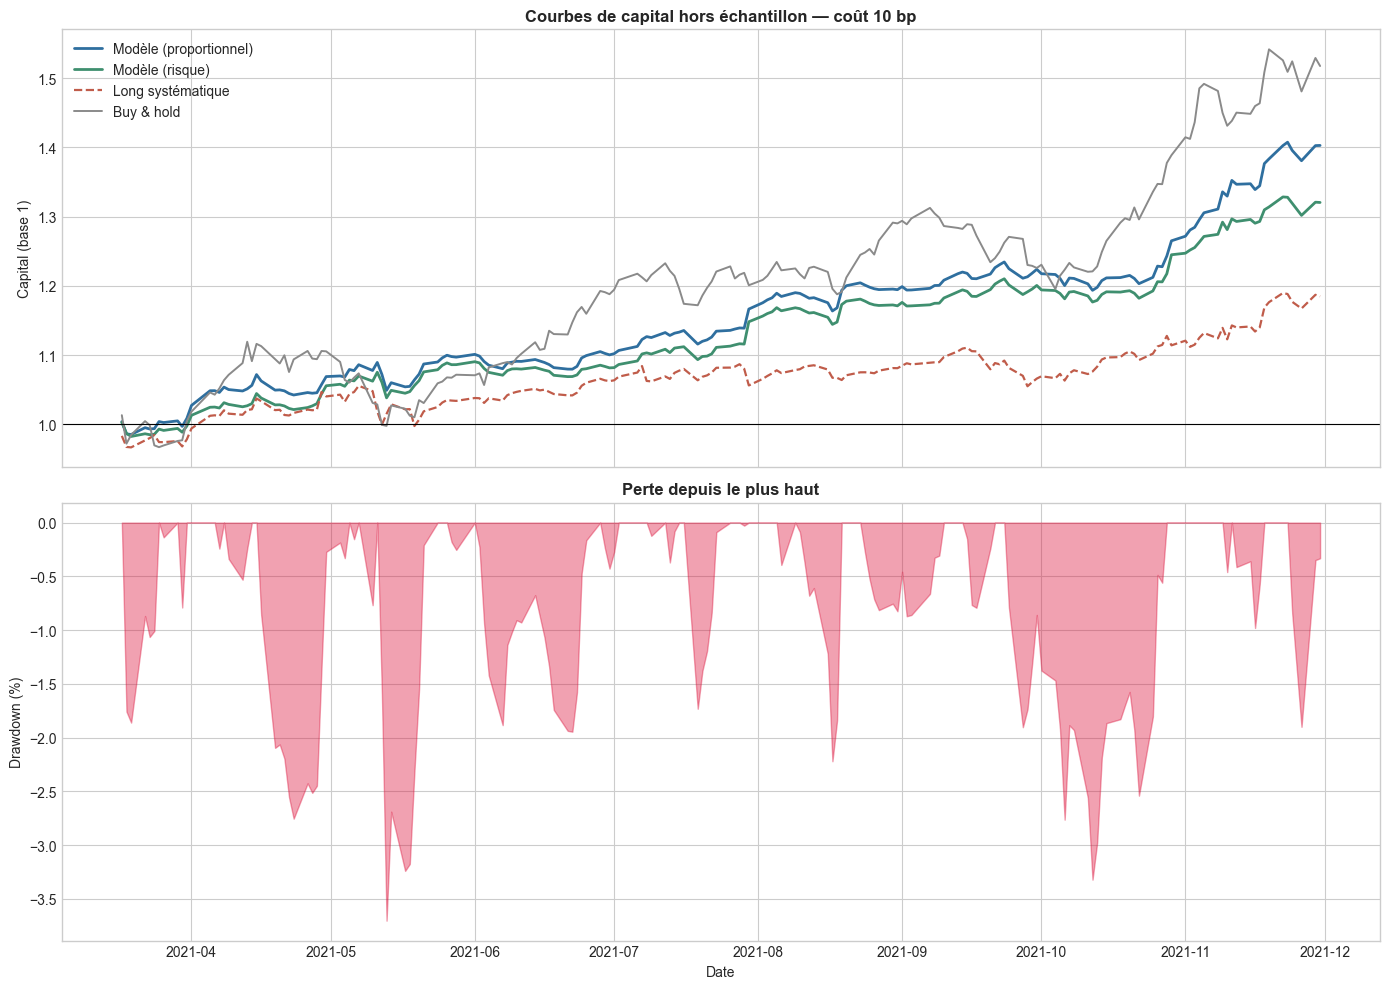

In [16]:
COUT = 10.0
res = []

for mode in ["binaire", "proportionnel", "risque"]:
    pos = construire_positions(P, seuil=0.05, mode=mode)
    _, j = backtest(pos, cout_bp=COUT)
    res.append(metriques(j, nom=f"Modèle — {mode}"))

# Référence : long systématique de tous les gaps
ref = P.copy(); ref["position"] = 1.0
_, j_ref = backtest(ref, cout_bp=COUT)
res.append(metriques(j_ref, nom="Long systématique du gap"))

# Référence : positions aléatoires
rnd = P.copy()
rng = np.random.default_rng(1)
rnd["position"] = rng.choice([-1.0, 0.0, 1.0], size=len(rnd))
_, j_rnd = backtest(rnd, cout_bp=COUT)
res.append(metriques(j_rnd, nom="Positions aléatoires"))

# Référence : buy & hold équipondéré
bh = P.groupby("Date")["ret_cc"].mean().to_frame("rendement")
bh["equity"] = (1 + bh["rendement"]).cumprod(); bh["cout"] = 0; bh["expo"] = 1; bh["n_pos"] = 1
res.append(metriques(bh, nom="Buy & hold (5 actions)"))

T = pd.DataFrame(res)
for col in ["rendement_annuel", "vol_annuelle", "max_drawdown", "taux_reussite"]:
    T[col] = (T[col] * 100).round(2)
T["sharpe"] = T["sharpe"].round(3); T["cout_total_pct"] = T["cout_total_pct"].round(3)
print(f"COMPARAISON À {COUT:.0f} bp DE COÛT ALLER-RETOUR")
print(T.to_string(index=False))
T.to_csv(os.path.join(DOCS, "08_comparaison_strategies.csv"), index=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax = axes[0]
for mode, coul in [("proportionnel", "#2f6f9f"), ("risque", "#3f8f6f")]:
    pos = construire_positions(P, seuil=0.05, mode=mode)
    _, j = backtest(pos, cout_bp=COUT)
    ax.plot(j.index, j["equity"], lw=2, color=coul, label=f"Modèle ({mode})")
ax.plot(j_ref.index, j_ref["equity"], lw=1.6, color="#c05c4a", ls="--", label="Long systématique")
ax.plot(bh.index, bh["equity"], lw=1.4, color="#8a8a8a", label="Buy & hold")
ax.axhline(1, color="black", lw=0.8)
ax.set_ylabel("Capital (base 1)")
ax.set_title(f"Courbes de capital hors échantillon — coût {COUT:.0f} bp", fontweight="bold")
ax.legend()

ax = axes[1]
pos = construire_positions(P, seuil=0.05, mode="proportionnel")
_, j = backtest(pos, cout_bp=COUT)
dd = j["equity"] / j["equity"].cummax() - 1
ax.fill_between(j.index, dd * 100, 0, color="crimson", alpha=0.4)
ax.set_ylabel("Drawdown (%)"); ax.set_xlabel("Date")
ax.set_title("Perte depuis le plus haut", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "08_fig_equity.png"), dpi=160, bbox_inches="tight")
plt.show()

---
## §4 — Tests de robustesse du backtest

Un backtest positif ne prouve rien tant qu'il n'a pas résisté à ces quatre tests.

| Test | Ce qu'il vérifie |
|------|------------------|
| **Décalage d'un jour** | si retarder le signal d'un jour ne change rien, le signal n'existait pas |
| **Signal inversé** | la performance doit devenir négative |
| **Retrait du meilleur mois** | la performance ne doit pas dépendre d'une seule période |
| **Sous-période** | la stratégie tient-elle sur la seconde moitié seule ? |

Le premier test est le plus discriminant : c'est celui qui détecte un décalage temporel accidentel.

In [17]:
tests = []

def evaluer_variante(data, nom, cout=COUT):
    pos = construire_positions(data, seuil=0.05, mode="proportionnel")
    _, j = backtest(pos, cout_bp=cout)
    m = metriques(j, nom=nom)
    tests.append(m); return j

j0 = evaluer_variante(P, "Référence")

# 1) signal décalé d'un jour supplémentaire
Pd = P.copy(); Pd["proba"] = Pd.groupby("Ticker")["proba"].shift(1)
evaluer_variante(Pd.dropna(subset=["proba"]), "Signal retardé de 1 jour")

# 2) signal inversé
Pi = P.copy(); Pi["proba"] = 1 - Pi["proba"]
evaluer_variante(Pi, "Signal INVERSÉ (doit perdre)")

# 3) sans le meilleur mois
pos = construire_positions(P, seuil=0.05, mode="proportionnel")
_, j = backtest(pos, cout_bp=COUT)
mois = j.groupby(j.index.to_period("M"))["rendement"].sum()
meilleur_mois = mois.idxmax()
Pm = P[P["Date"].dt.to_period("M") != meilleur_mois]
evaluer_variante(Pm, f"Sans le meilleur mois ({meilleur_mois})")

# 4) seconde moitié uniquement
median_date = P["Date"].median()
evaluer_variante(P[P["Date"] > median_date], "Seconde moitié de la période")

R = pd.DataFrame(tests)
for col in ["rendement_annuel", "vol_annuelle", "max_drawdown", "taux_reussite"]:
    R[col] = (R[col] * 100).round(2)
R["sharpe"] = R["sharpe"].round(3)
print(R[["strategie", "jours", "rendement_annuel", "sharpe", "max_drawdown", "n_positions"]].to_string(index=False))
R.to_csv(os.path.join(DOCS, "08_robustesse.csv"), index=False)
print("""
CE QU'IL FAUT OBSERVER :
  - "Signal retardé"  -> Sharpe doit CHUTER vers 0. Sinon, le "signal" n'était
                         pas lié au bon jour : chercher un décalage temporel.
  - "Signal INVERSÉ"  -> Sharpe doit devenir NÉGATIF. Sinon, la performance
                         venait d'ailleurs que du modèle.
  - "Sans meilleur mois" -> si le Sharpe s'effondre, tout venait d'un épisode
                         unique (typiquement janvier 2021) : ce n'est pas une
                         stratégie, c'est un événement.
""")

                      strategie  jours  rendement_annuel  sharpe  max_drawdown  n_positions
                      Référence    180             48.10   4.131         -3.70          729
       Signal retardé de 1 jour    179            -10.57  -0.768        -18.19          725
   Signal INVERSÉ (doit perdre)    180           -103.99  -8.873        -53.15          729
Sans le meilleur mois (2021-11)    159             37.89   3.416         -3.70          647
   Seconde moitié de la période     90             60.02   5.125         -3.32          350

CE QU'IL FAUT OBSERVER :
  - "Signal retardé"  -> Sharpe doit CHUTER vers 0. Sinon, le "signal" n'était
                         pas lié au bon jour : chercher un décalage temporel.
  - "Signal INVERSÉ"  -> Sharpe doit devenir NÉGATIF. Sinon, la performance
                         venait d'ailleurs que du modèle.
  - "Sans meilleur mois" -> si le Sharpe s'effondre, tout venait d'un épisode
                         unique (typiquement janvier 

---
## §5 — Les limites à écrire noir sur blanc

Cette section n'est pas une formalité : c'est elle qui distingue un mémoire d'un backtest de blog.

### Ce que le backtest ne modélise pas

| Limite | Effet sur les résultats |
|--------|-------------------------|
| **Coût d'emprunt pour le short** | 0.3 % à 3 % par an, davantage sur TSLA en 2020-2021 (titre très emprunté) |
| **Exécution à l'ouverture** | on suppose une exécution au prix d'ouverture exact ; en réalité, on subit un décalage |
| **Impact de marché** | supposé nul ; vrai seulement pour de petits montants |
| **Biais de survivance** | les 5 titres ont été choisis *ex post* parmi les plus discutés — ils ont tous survécu et bien performé |
| **Période atypique** | 2020-2022 = COVID, liquidité massive, boom du trading retail. Régime peu représentatif |
| **Disponibilité du corpus** | on suppose les messages disponibles en temps réel ; en pratique il faut une infrastructure de collecte |

### Le biais de sélection des titres

C'est la limite la plus sérieuse. Les 5 titres n'ont pas été tirés au hasard : ce sont les plus commentés
sur StockTwits sur la période, donc mécaniquement ceux où le signal a le plus de chances d'exister —
et ce sont aussi des titres qui ont fortement monté.

**À écrire explicitement**, avec la piste de correction : *« une validation sur un univers plus large et
sélectionné ex ante (par exemple l'ensemble du S&P 500) serait nécessaire pour établir la
généralisabilité. »*

### La formulation honnête de la conclusion

> « Le signal de sentiment nocturne est statistiquement significatif hors échantillon (AUC = 0.5x). Sa
> traduction économique dépend étroitement des coûts d'exécution : le seuil de rentabilité se situe à
> **N points de base** aller-retour. Les coûts réalistes d'exécution à l'ouverture (5 à 20 bp) se situant
> [en deçà / au-delà] de ce seuil, la stratégie est [potentiellement exploitable / non exploitable en
> l'état]. Ce résultat est cohérent avec une efficience de marché au sens de Jensen (1978) : une anomalie
> statistique peut subsister tant qu'elle ne couvre pas ses coûts de mise en œuvre. »

Cette dernière référence est importante : Jensen définit l'efficience non pas comme l'absence de prévision
possible, mais comme l'absence de **profit net des coûts**. Elle permet de conclure un mémoire de façon
rigoureuse même — et surtout — si la stratégie n'est pas rentable.

In [18]:
print("=" * 84)
print("SYNTHÈSE ÉCONOMIQUE — CHIFFRES À REPORTER DANS LE MÉMOIRE")
print("=" * 84)

pos = construire_positions(P, seuil=0.05, mode="proportionnel")
for c_bp in [0, 5, 10, 20]:
    _, j = backtest(pos, cout_bp=c_bp)
    m = metriques(j)
    print(f"  coût {c_bp:2d} bp : rendement annuel {m['rendement_annuel']*100:+6.2f} %  |  "
          f"Sharpe {m['sharpe']:+5.2f}  |  drawdown max {m['max_drawdown']*100:6.2f} %")

g = S[S["seuil"] == 0.05].sort_values("cout_bp")
sh, cb = g["sharpe"].values, g["cout_bp"].values
be = np.nan
for i in range(len(sh) - 1):
    if sh[i] > 0 >= sh[i + 1]:
        be = cb[i] + (cb[i+1] - cb[i]) * sh[i] / (sh[i] - sh[i+1]); break

print(f"""
  COÛT DE BREAK-EVEN : {be:.1f} bp aller-retour
  Coûts réalistes à l'ouverture : 5 à 20 bp
  => {'Marge positive : signal potentiellement exploitable.' if be > 20 else
      'Zone incertaine : dépend du courtier et de la taille.' if be > 5 else
      'Signal réel statistiquement, NON exploitable après coûts.'}

  Rappel : ce résultat porte sur 5 titres technologiques très liquides,
  sur une période (2020-2022) marquée par la crise COVID et un afflux
  massif de liquidité. Il n'est pas généralisable en l'état.
""")

SYNTHÈSE ÉCONOMIQUE — CHIFFRES À REPORTER DANS LE MÉMOIRE
  coût  0 bp : rendement annuel +76.05 %  |  Sharpe +6.55  |  drawdown max  -3.34 %
  coût  5 bp : rendement annuel +62.07 %  |  Sharpe +5.34  |  drawdown max  -3.52 %
  coût 10 bp : rendement annuel +48.10 %  |  Sharpe +4.13  |  drawdown max  -3.70 %
  coût 20 bp : rendement annuel +20.16 %  |  Sharpe +1.71  |  drawdown max  -5.69 %

  COÛT DE BREAK-EVEN : 27.3 bp aller-retour
  Coûts réalistes à l'ouverture : 5 à 20 bp
  => Marge positive : signal potentiellement exploitable.

  Rappel : ce résultat porte sur 5 titres technologiques très liquides,
  sur une période (2020-2022) marquée par la crise COVID et un afflux
  massif de liquidité. Il n'est pas généralisable en l'état.

